# Imports & Functions

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)
from sklearn.model_selection import GridSearchCV
import statsmodels.formula.api as smf
from itertools import combinations
from sklearn.preprocessing import StandardScaler
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

In [2]:
def evaluate_model(y_test, y_pred, y_prob, plot_conf_matx=False):
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    print("Accuracy:", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall:", round(recall,4))
    print("F1-score:", round(f1,4))
    print("ROC-AUC:", round(auc,4))

    if plot_conf_matx:
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()

In [71]:
def plot_col_vals(ax, col, title=None):
    y = df[col]
    x = y.index

    ax.scatter(x, y, alpha=0.7, s=20)
    ax.set_xlabel("Index")
    ax.set_ylabel(col)
    ax.set_title(title if title else f"Scatter of {col}")
    ax.grid(True, linestyle="--", alpha=0.4)

# Load Data

After data cleaning and duplicate removal, the final dataset contains 1,650 records and 72 features.

The table below provides an overview of the first 10 records in the cleaned dataset:

In [3]:
df = pd.read_csv("final_cleaned_data.csv")

print(df.shape)
df.head(10)

(1650, 72)


,index,id,moth_age,moth_weight,moth_height,parent_relat,race,num_preg,num_births,num_stillborns,...,kidney_eval,fetal_bladder_eval,placenta_vessels_eval,fetal_limbs_eval,nb_attachment_eval,spinal_processes_eval,preeclampsia,no_diabetes,prev_diabetes,pregnancy_diabetes
0,1,213997.0,36.0,72.0,160.0,1.0,0.0,6.0,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2,1279574.0,39.0,72.0,159.5,0.0,0.0,4.0,4.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,3,2319555.0,21.0,72.0,159.5,0.0,1.0,2.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,4,2518474.0,29.0,66.0,161.0,1.0,0.0,2.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,5,2528353.0,26.0,69.0,150.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5,6,2632151.0,33.0,72.0,159.5,1.0,0.0,3.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6,7,2748448.0,36.0,68.0,164.0,1.0,0.0,4.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7,8,2617641.0,38.0,72.0,159.5,0.0,1.0,3.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
8,9,1891426.0,27.0,72.0,159.5,0.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9,10,599320.0,28.0,83.5,156.0,0.0,0.0,3.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [4]:
# drop "index" and "id" (not used in analysis)
df = df.drop(columns=["index", "id"])
df.head()

,moth_age,moth_weight,moth_height,parent_relat,race,num_preg,num_births,num_stillborns,num_maternal_deaths,cnt_abortions,...,kidney_eval,fetal_bladder_eval,placenta_vessels_eval,fetal_limbs_eval,nb_attachment_eval,spinal_processes_eval,preeclampsia,no_diabetes,prev_diabetes,pregnancy_diabetes
0,36.0,72.0,160.0,1.0,0.0,6.0,4.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,39.0,72.0,159.5,0.0,0.0,4.0,4.0,4.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,21.0,72.0,159.5,0.0,1.0,2.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,29.0,66.0,161.0,1.0,0.0,2.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,26.0,69.0,150.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Among the 70 remaining variables, **38** are categorical and **32** are numerical.

A subset of these variables and their corresponding data types is presented below:

In [5]:
# Change type for categoricals
binary_cols = [col for col in df.columns if (df[col].nunique() == 2 or df[col].nunique() == 1)]

df[binary_cols] = df[binary_cols].astype('category')

print(f"Changed {len(binary_cols)} columns to category type.")
print("\nData types after conversion:")
print(df.dtypes)

Changed 38 columns to category type.

Data types after conversion:
moth_age                  float64
moth_weight               float64
moth_height               float64
parent_relat             category
race                     category
                           ...   
spinal_processes_eval    category
preeclampsia             category
no_diabetes              category
prev_diabetes            category
pregnancy_diabetes       category
Length: 70, dtype: object


Among the 1,650 observations, 809 deliveries were **vaginal** (coded as 0), whereas 841 deliveries were performed via **cesarean** section (coded as 1):

In [6]:
# Extract Labels from other features
features = df.drop("delivery_method", axis=1)
labels = df["delivery_method"]

In [7]:
# 809 Vaginal
len([l for l in labels if l == 0])

809

In [8]:
# 841 Cesarean
len([l for l in labels if l == 1])

841

# Finding Best Model

## Baseline Model with All Features
Random Forest, XGBClassifier, CatBoostClassifier

In [12]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    features, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

Accuracy: 0.8152
Precision: 0.7512
Recall: 0.9524
F1-score: 0.8399
ROC-AUC: 0.8629


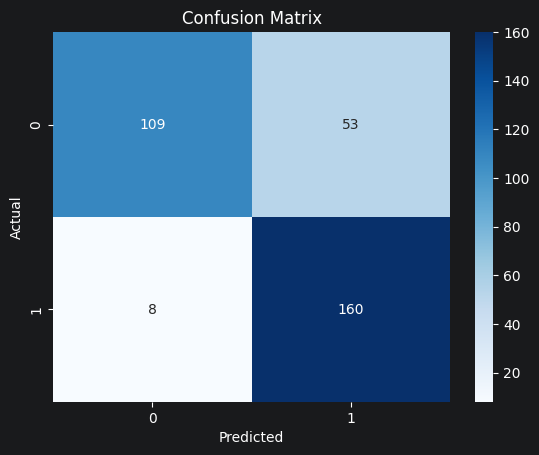

In [13]:
############ Random Forest ############
rfmodel = RandomForestClassifier(
    n_estimators=500, 
    random_state=42,
    n_jobs=-1
)

rfmodel.fit(X_train, y_train)

y_pred = rfmodel.predict(X_test)

# Probability of positive class (for AUC)
y_prob = rfmodel.predict_proba(X_test)[:,1]

evaluate_model(y_test, y_pred, y_prob, plot_conf_matx=True)

Accuracy: 0.7909
Precision: 0.7538
Recall: 0.875
F1-score: 0.8099
ROC-AUC: 0.8604


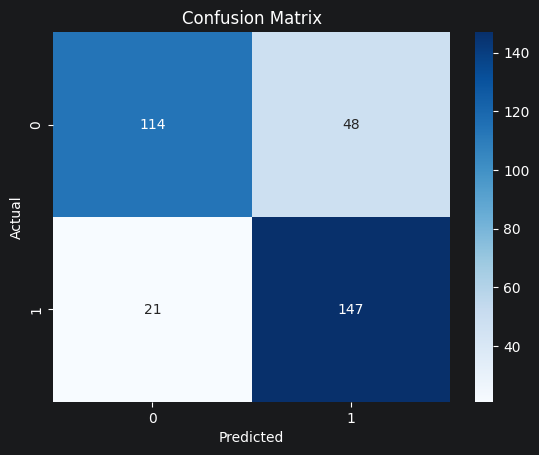

In [34]:
############ XGBClassifier ############  (To run this, skip the cell that change types of categorical to Categorical)
xgbmodel = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05
)

xgbmodel.fit(X_train, y_train)

y_pred = xgbmodel.predict(X_test)

# Probability of positive class (for AUC)
y_prob = xgbmodel.predict_proba(X_test)[:,1]

evaluate_model(y_test, y_pred, y_prob, plot_conf_matx=True)

0:	total: 57.5ms	remaining: 17.2s
100:	total: 133ms	remaining: 261ms
200:	total: 196ms	remaining: 96.4ms
299:	total: 255ms	remaining: 0us
Accuracy: 0.8
Precision: 0.7656
Recall: 0.875
F1-score: 0.8167
ROC-AUC: 0.8647


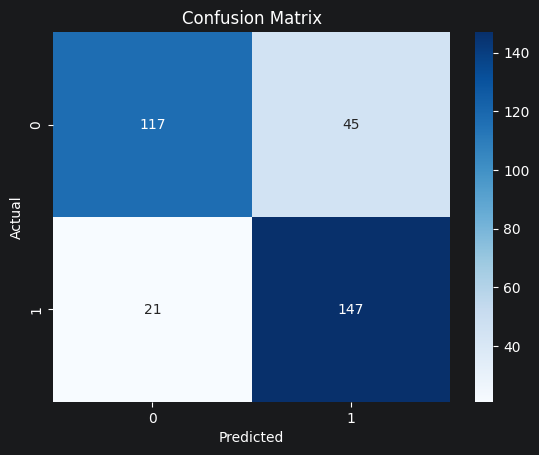

In [38]:
############ CatBoostClassifier ############   (Used for clinical data with categorical features)
cat_cols = features.select_dtypes(include=['category']).columns
features[cat_cols] = features[cat_cols].astype(str)
cat_features = [features.columns.get_loc(col) for col in cat_cols]

X_train, X_test, y_train, y_test = train_test_split(
    features, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

catmodel = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.03,
    l2_leaf_reg=5,
    subsample=1.0,
    eval_metric='AUC',
    random_seed=42,
    verbose=100,
    cat_features=cat_features
)

catmodel.fit(X_train, y_train)

y_pred = catmodel.predict(X_test)

# Probability of positive class (for AUC)
y_prob = catmodel.predict_proba(X_test)[:,1]

evaluate_model(y_test, y_pred, y_prob, plot_conf_matx=True)

Three machine learning models were evaluated, selected for their suitability for clinical datasets with mixed feature types (categorical and numerical). Model performance was assessed using accuracy, precision, recall, F1-score, and confusion matrices, as presented above.

**Interpretation of the Random Forest Model Results:**
* Accuracy (0.8152):
This means that the model correctly predicted the delivery type in about 81.5% of all cases.
In other words, if we look at all mothers in the dataset, about 8 out of 10 predictions made by the model were correct.
* Precision (0.7512):
Precision answers the question: “When the model predicts a cesarean delivery, how often is it correct?”
A value of 0.75 means that about 75% of the predicted cesarean cases were truly cesarean, while the rest were incorrectly labeled as cesarean.
* Recall (0.9524):
Recall answers: “Out of all actual cesarean deliveries, how many did the model correctly identify?”
A value of 0.95 means the model is very good at detecting cesarean cases — it identifies about 95% of all true cesarean deliveries.
* F1-score (0.8399):
This is a balance between precision and recall.
It shows that the model performs well overall in detecting cesarean cases while maintaining reasonable accuracy in its positive predictions.
* ROC-AUC (0.8629):
This measures how well the model can distinguish between vaginal and cesarean deliveries across all decision thresholds.
A value of 0.86 indicates a strong ability to separate the two groups, meaning the model is generally reliable in ranking patients by risk.

**Confusion Matrix interpretation:**
* True Negatives (TN = 109): The model correctly predicted vaginal delivery (class 0) for 109 mothers.
* False Positives (FP = 53): The model predicted cesarean delivery, but the actual outcome was vaginal delivery for 53 mothers → These represent unnecessary “alarm” cases.
* False Negatives (FN = 8): The model predicted vaginal delivery, but the actual outcome was cesarean delivery for 8 mothers → These are clinically **more important** because the model missed a cesarean case.
* True Positives (TP = 160): The model correctly predicted cesarean delivery (class 1) for 160 mothers.

Among the three evaluated models, the Random Forest model demonstrates the best overall performance.
This conclusion is supported by two key observations:
1. Highest F1-score

    The Random Forest model achieved the highest F1-score among all models. This metric is particularly important in this study because it provides a balanced evaluation of performance by combining both precision and recall. In clinical prediction tasks, this balance is essential, as it reflects both the correctness of positive predictions and the ability to detect actual positive cases.

2. Lowest False Negative Rate

    The confusion matrix shows that the Random Forest model produces the fewest false negatives, which is a critical advantage in this context. In this problem, there are two types of classification errors:
    * False Positive: The model predicts a cesarean delivery, but the actual outcome is vaginal delivery.
    * False Negative: The model predicts a vaginal delivery, but the actual outcome is a cesarean delivery.

    Among these, false negatives are more clinically concerning, as they represent cases where a necessary cesarean delivery is not identified by the model, potentially leading to higher medical risk.

   The Random Forest model significantly reduces the number of false negatives, even though this comes at the cost of a higher number of false positives. From a clinical safety perspective, this trade-off is often acceptable, as it prioritizes minimizing missed high-risk cases.

## Most Important Features

After the previous evaluation and identifying Random Forest (RF) as the best-performing model, we use the `feature_importances_` attribute to determine the most influential variables in the model’s predictions.

This method estimates the importance of each feature by measuring how much each one contributes to reducing uncertainty (impurity) across all decision trees in the forest. In simpler terms, features that are more frequently used to make accurate splits in the trees are assigned higher importance scores.

The 10 most important features are listed below and there is a plot of every features' calculated importance value:


In [14]:
# Extract Feature Importances
importances = rfmodel.feature_importances_
feature_names = features.columns

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values(by="importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 10 Most Important Features:")
importance_df.head(10)

Top 10 Most Important Features:


,feature,importance
0,fetal_weight_estimation,0.136897
1,fetal_heart_rate_eval,0.083844
2,lips_nose_eval,0.065030
3,temporal_bone_diameter,0.055411
4,blood_nitrogen_level,0.045474
5,nuchal_skin_fold,0.038086
6,moth_age,0.037131
7,fetal_femur_length,0.035974
8,thyroid_stimulating_hormone,0.034828
9,fetal_head_circumference,0.033603


All features with their importances are plotted below:

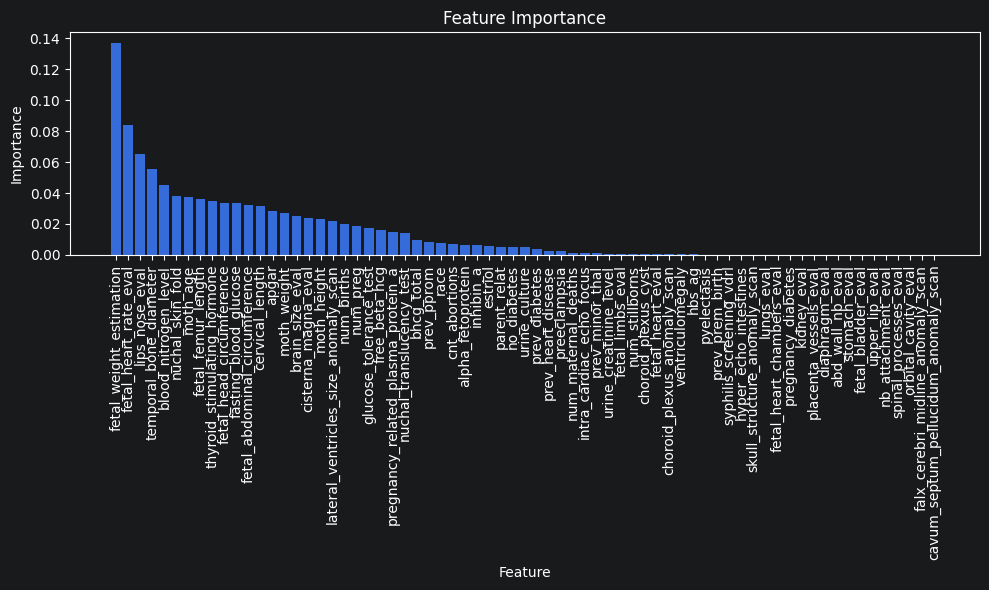

In [15]:
plt.figure(figsize=(10, 6))

plt.bar(importance_df["feature"], importance_df["importance"])

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance")

# Rotate labels so they don't overlap
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

## RF Model with Top-K Features

In [16]:
# Evaluate top-k subsets
top_ks = [10, 30, 40, 45, 50]

for k in top_ks:
    topk_features = importance_df.head(k)["feature"].tolist()
    model_k = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
    model_k.fit(X_train[topk_features], y_train)
    y_pred_k = model_k.predict(X_test[topk_features])
    y_prob_k = model_k.predict_proba(X_test[topk_features])[:,1]
    print(f"---- k = {k} ---- ")
    evaluate_model(y_test, y_pred_k, y_prob_k)    

---- k = 10 ---- 
Accuracy: 0.7879
Precision: 0.7402
Recall: 0.8988
F1-score: 0.8118
ROC-AUC: 0.845
---- k = 30 ---- 
Accuracy: 0.8121
Precision: 0.75
Recall: 0.9464
F1-score: 0.8368
ROC-AUC: 0.8614
---- k = 40 ---- 
Accuracy: 0.8182
Precision: 0.7547
Recall: 0.9524
F1-score: 0.8421
ROC-AUC: 0.8636
---- k = 45 ---- 
Accuracy: 0.8182
Precision: 0.7547
Recall: 0.9524
F1-score: 0.8421
ROC-AUC: 0.8617
---- k = 50 ---- 
Accuracy: 0.8061
Precision: 0.75
Recall: 0.9286
F1-score: 0.8298
ROC-AUC: 0.8652


We then investigated whether a reduced set of the most important features could achieve comparable or even better performance than using all available features.

To do this, we retrained the Random Forest model using only the top-ranked features based on `feature_importances_`, testing different feature set sizes (e.g., top 10, 20, 30, and so on).

The results showed that using the top **45 features** provided the best performance compared to both smaller and larger feature subsets, suggesting that this subset captures the most relevant information while avoiding unnecessary noise from less important variables.


## Grid Search on RF using Top-45 Features

Next, we applied **Grid Search Cross-Validation** to optimize the hyperparameters of the Random Forest model, using the previously selected top 45 features.

This process systematically evaluates different combinations of parameters to identify the configuration that yields the best model performance on the data.

The optimal parameters found by Grid Search are as follows:

**Best RF parameters:**

```python
{'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 1500}
```


In [13]:
k = 45
topk_features = importance_df.head(k)["feature"].tolist()

param_grid = {
    'n_estimators': [1500],  # 500, 1000,
    'max_depth': [None],  # 4, 6, 8, 10,
    'min_samples_split': [2],  # , 5, 10
    'min_samples_leaf': [1],   # , 2, 4
    'max_features': ['sqrt']  # , 'log2'
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train[topk_features], y_train)

best_rf = grid.best_estimator_
print(grid.best_params_)

# Final RF Model

This section presents the results of the final Random Forest model, which was trained using the tuned hyperparameters and the top 45 most important features.

When compared to the initial Random Forest model trained earlier, the final model achieves a higher F1-score and demonstrates improved classification performance. In particular, the confusion matrix shows a reduction in incorrect predictions, indicating better overall balance between precision and recall.

In [37]:
features = df.drop("delivery_method", axis=1)
labels = df["delivery_method"]   # 809 natural, 841 cesarean

In [38]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    features, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

Accuracy: 0.8242
Precision: 0.7594
Recall: 0.9583
F1-score: 0.8474
ROC-AUC: 0.8634


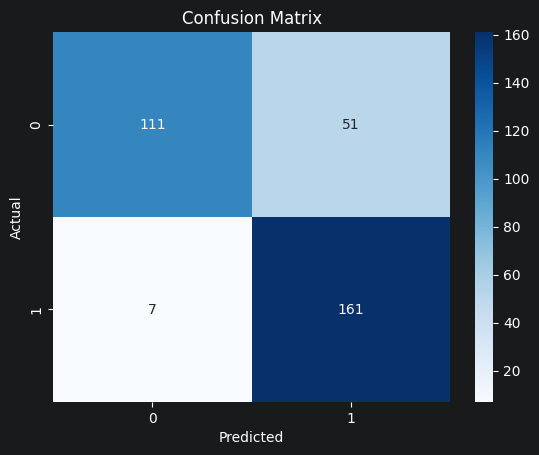

In [39]:
k = 45
topk_features = importance_df.head(k)["feature"].tolist()
X = X_train[topk_features]
y = y_train

best_rf = RandomForestClassifier(
    n_estimators=1500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

best_rf.fit(X, y)

y_pred = best_rf.predict(X_test[topk_features])

# Probability of positive class (for AUC)
y_prob = best_rf.predict_proba(X_test[topk_features])[:,1]

evaluate_model(y_test, y_pred, y_prob, plot_conf_matx=True)

## Most Important Features

In [41]:
## Most Important Features
# Extract Feature Importances
importances = best_rf.feature_importances_
feature_names = topk_features

importance_df_normal = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values(by="importance", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 10 Most Important Features:")
importance_df_normal.head(10)


Top 10 Most Important Features:


,feature,importance
0,fetal_weight_estimation,0.144654
1,fetal_heart_rate_eval,0.088712
2,lips_nose_eval,0.067376
3,temporal_bone_diameter,0.056600
4,blood_nitrogen_level,0.044424
5,nuchal_skin_fold,0.037428
6,moth_age,0.036304
7,fetal_femur_length,0.035884
8,thyroid_stimulating_hormone,0.034870
9,fetal_abdominal_circumference,0.033108


# RF with Most Stable Columns

For further analysis, we explored whether feature selection based on data completeness could improve model performance. Specifically, we selected features with fewer missing values by removing 14 columns that each contained more than 1,000 NaN values out of 1,650 total records.

The excluded columns are listed below:

In [27]:
# Remove 14 columns with more than 1000 Nan values
cols_many_nans = ['moth_weight', 'moth_height', 'blood_nitrogen_level',
       'nuchal_translucency_test', 'pregnancy_related_plasma_protein_a',
       'free_beta_hcg', 'alpha_fetoprotein', 'estriol', 'inhibin_a',
       'bhcg_total', 'lateral_ventricles_size_anomaly_scan', 'brain_size_eval',
       'cisterna_magna_eval', 'lips_nose_eval']

small_df = df.drop(columns=cols_many_nans)

print(small_df.shape)

(1650, 56)


Accuracy: 0.7939
Precision: 0.7294
Recall: 0.9464
F1-score: 0.8238
ROC-AUC: 0.8461


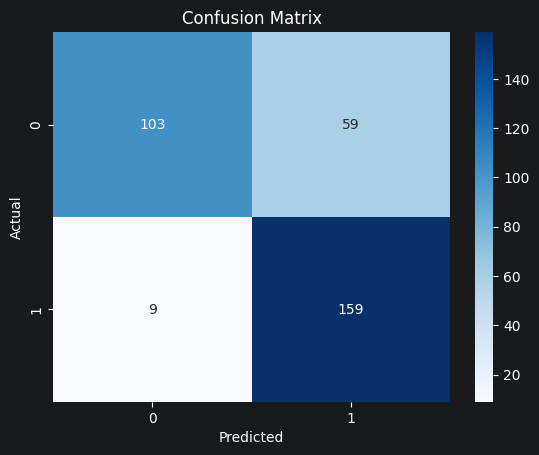

In [28]:
features = small_df.drop("delivery_method", axis=1)
labels = small_df["delivery_method"] 

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, 
    test_size=0.2, 
    random_state=42,
    stratify=labels
)

# Train Random Forest
model = RandomForestClassifier(
    n_estimators=1500,
    max_depth=None, 
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

evaluate_model(y_test, y_pred, y_prob, plot_conf_matx=True)

After retraining the tuned Random Forest model using this reduced dataset, the results showed a decline in performance compared to the final model (which used the top 45 most important features). In particular, both accuracy and the number of false predictions worsened across classes.

Interestingly, even though this new model used 56 features (more than the 45 features in the final model), it performed worse. This suggests that:

1. Not all features are equally useful for prediction; including less informative features can reduce model effectiveness.
2. Feature removal should not be based solely on missing values, as variables with many NaNs may still carry important predictive information. Removing them can lead to a loss of valuable signal in the data.


## Most Important Features

Here are the most important features, among those we used in this analysis:

In [25]:
# Extract Feature Importances
importances = model.feature_importances_
feature_names = features.columns

importance_df_best = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values(by="importance", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 10 Most Important Features:")
importance_df_best.head(10)


Top 10 Most Important Features:


,feature,importance
0,fetal_weight_estimation,0.176445
1,fetal_heart_rate_eval,0.111174
2,temporal_bone_diameter,0.079949
3,nuchal_skin_fold,0.064636
4,moth_age,0.059035
5,thyroid_stimulating_hormone,0.057976
6,fasting_blood_glucose,0.053067
7,cervical_length,0.048794
8,fetal_femur_length,0.048487
9,fetal_head_circumference,0.048327


# RF with Least Stable Columns

Similar to the previous experiment, we also evaluated the effect of retaining only the least reliable features — specifically, those with the highest number of missing values.

For this purpose, we selected 26 columns that each contained more than 500 NaN values, along with the target label.

The selected columns used in this analysis are listed below:

In [29]:
# Keep 26 columns with more than 500 Nan values + label
cols_many_nans = ['moth_weight', 'moth_height', 'blood_nitrogen_level',
       'urine_creatinine_level', 'hbs_ag', 'syphilis_screening_vdrl',
       'glucose_tolerance_test', 'nuchal_translucency_test',
       'pregnancy_related_plasma_protein_a', 'free_beta_hcg',
       'alpha_fetoprotein', 'estriol', 'inhibin_a', 'bhcg_total',
       'temporal_bone_diameter', 'fetal_head_circumference',
       'fetal_abdominal_circumference', 'fetal_femur_length',
       'cervical_length', 'nuchal_skin_fold',
       'lateral_ventricles_size_anomaly_scan', 'brain_size_eval',
       'cisterna_magna_eval', 'lips_nose_eval', 'fetal_heart_rate_eval',
       'preeclampsia', "delivery_method"]
small_df = df[cols_many_nans]
print(small_df.shape)

(1650, 27)


Accuracy: 0.7939
Precision: 0.7451
Recall: 0.9048
F1-score: 0.8172
ROC-AUC: 0.8387


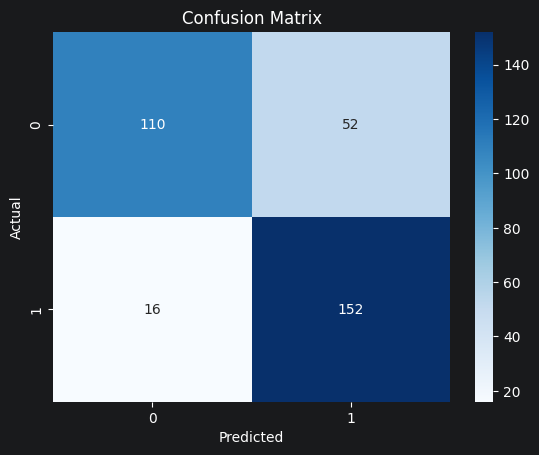

In [30]:
features = small_df.drop("delivery_method", axis=1)
labels = small_df["delivery_method"] 

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, 
    test_size=0.2, 
    random_state=42,
    stratify=labels
)

# Train Random Forest
model = RandomForestClassifier(
    n_estimators=1500,
    max_depth=None, 
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Probability of positive class (for AUC)
y_prob = model.predict_proba(X_test)[:,1]

evaluate_model(y_test, y_pred, y_prob, plot_conf_matx=True)

As expected, the model performance significantly deteriorated in this scenario compared to all previous experiments. Using only 26 features that are sparsely populated and less informative resulted in insufficient data for accurate classification.

## Most Important Features

Again, we tried to find the most important features in this scenario as well:

In [31]:
# Extract Feature Importances
importances = model.feature_importances_
feature_names = features.columns

importance_df_worst = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values(by="importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 10 Most Important Features:")
importance_df_worst.head(10)

Top 10 Most Important Features:


,feature,importance
0,fetal_heart_rate_eval,0.142422
1,lips_nose_eval,0.103766
2,temporal_bone_diameter,0.096473
3,blood_nitrogen_level,0.062597
4,nuchal_skin_fold,0.060208
5,fetal_femur_length,0.058473
6,moth_weight,0.050099
7,fetal_abdominal_circumference,0.047966
8,cervical_length,0.047700
9,fetal_head_circumference,0.046096


# Plot importance of features

At this stage, we have evaluated three different Random Forest models under different feature-selection strategies:

1. The final tuned Random Forest model using the top 45 most important features
2. The tuned model using the most stable features (i.e., columns with the fewest missing values)
3. The tuned model using the least stable features (i.e., columns with the highest number of missing values)

In the previous sections, we compared these models in terms of accuracy and overall predictive performance. Here, we extend the comparison by analyzing and contrasting the feature importance values across the three scenarios.

The table below presents the feature importance scores for each feature under each model configuration:

In [42]:
# merge 3 importance dataframes
imp_df = (
    importance_df_normal
    .rename(columns={'importance': 'normal'})
    .merge(
        importance_df_best.rename(columns={'importance': 'best'}),
        on='feature',
        how='outer'
    )
    .merge(
        importance_df_worst.rename(columns={'importance': 'worst'}),
        on='feature',
        how='outer'
    )
)
print(imp_df.shape)
imp_df.head(10)

(69, 4)


,feature,normal,best,worst
0,abd_wall_nb_eval,NaN,0.000000,NaN
1,alpha_fetoprotein,0.005853,NaN,0.008334
2,apgar,0.028039,0.031516,NaN
3,bhcg_total,0.008693,NaN,0.011292
4,blood_nitrogen_level,0.044424,NaN,0.062597
5,brain_size_eval,0.025594,NaN,0.037213
6,cavum_septum_pellucidum_anomaly_scan,NaN,0.000000,NaN
7,cervical_length,0.030326,0.048794,0.047700
8,choroid_plexus_anomaly_scan,NaN,0.001062,NaN
9,choroid_plexus_cyst,0.000801,0.001793,NaN


In [47]:
df_long = imp_df.melt(
    id_vars='feature',
    value_vars=['worst', 'normal', 'best'],
    var_name='scenario',
    value_name='importance'
)

order = imp_df.sort_values('normal', ascending=True)['feature']

df_long['feature'] = pd.Categorical(
    df_long['feature'],
    categories=order,
    ordered=True
)

print(df_long.shape)
df_long.head()

(207, 3)


,feature,scenario,importance
0,abd_wall_nb_eval,worst,NaN
1,alpha_fetoprotein,worst,0.008334
2,apgar,worst,NaN
3,bhcg_total,worst,0.011292
4,blood_nitrogen_level,worst,0.062597


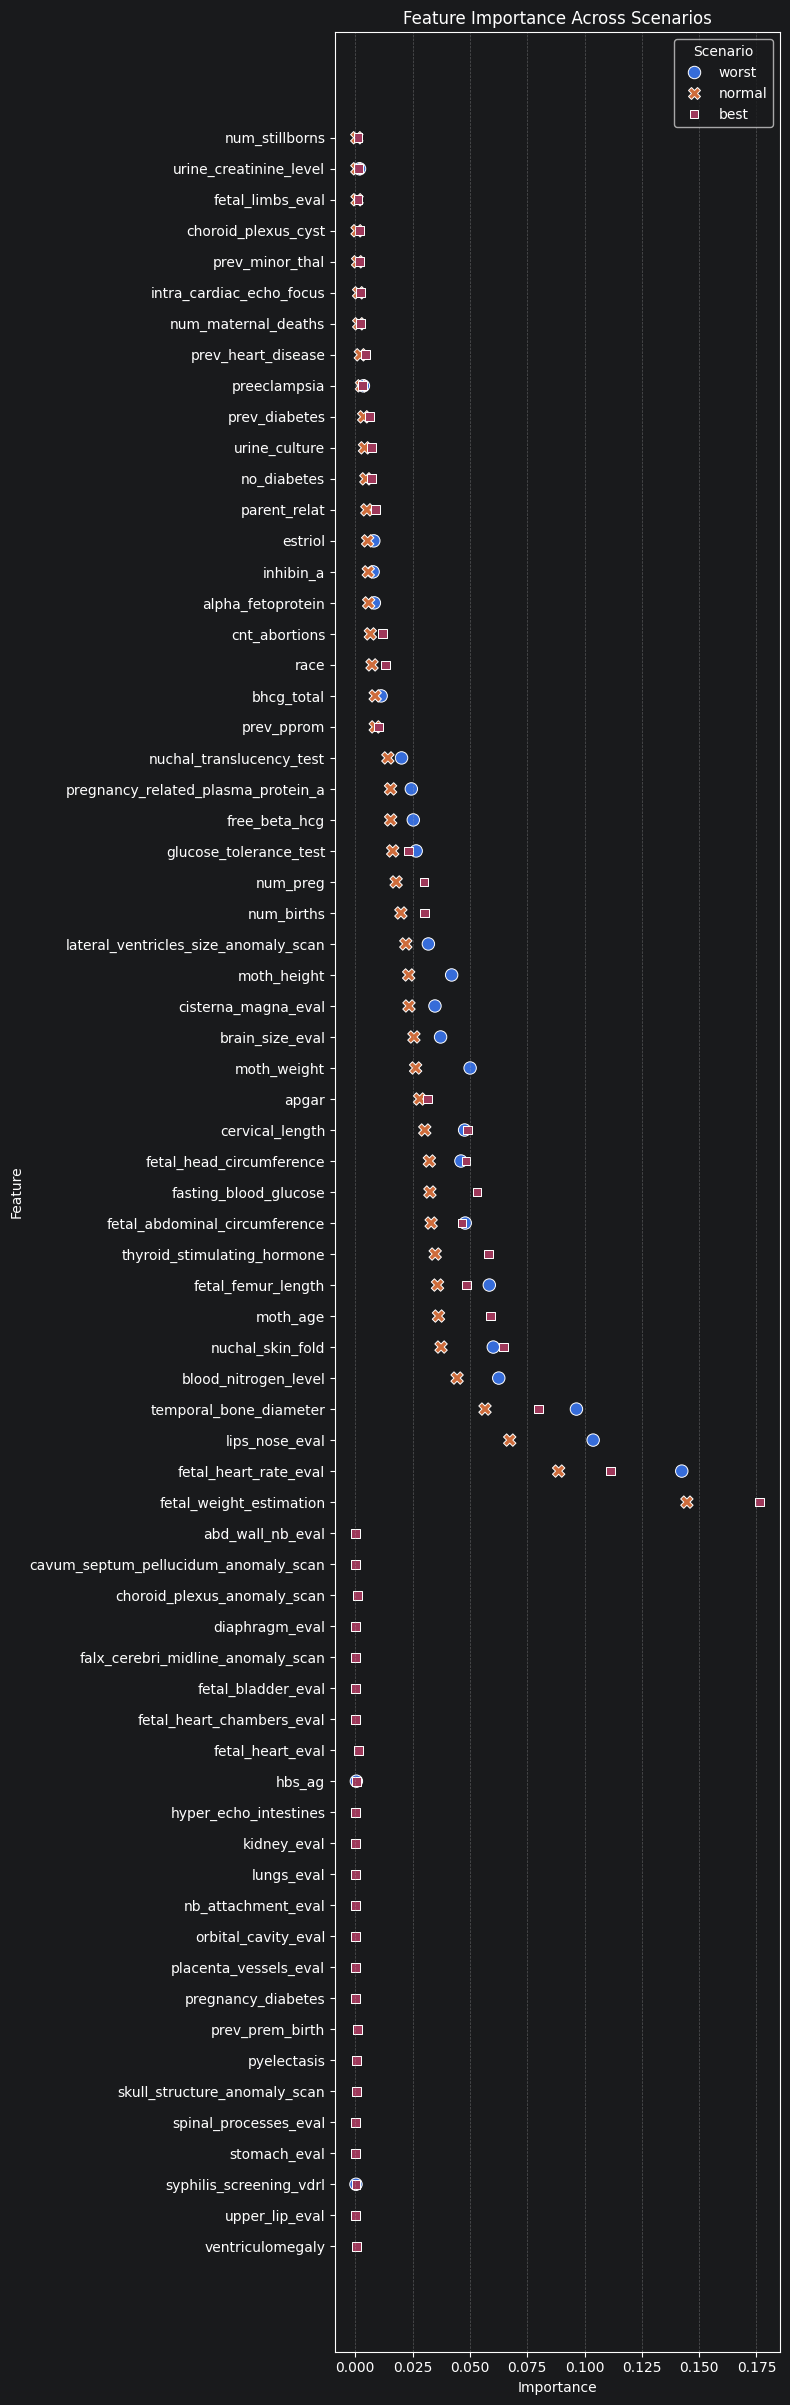

In [48]:
plt.figure(figsize=(8, max(6, len(imp_df['feature']) * 0.35)))

sns.scatterplot(
    data=df_long,
    x='importance',
    y='feature',
    hue='scenario',
    style='scenario',
    s=80
)

plt.title('Feature Importance Across Scenarios')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.legend(title='Scenario')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

The previous visualization illustrates the feature importance values for each feature across the three different modeling scenarios.

Several patterns can be observed:

* Features that appear in all three scenarios tend to show the highest importance in the worst-performing model. This is likely because, when fewer features are available, the model relies more heavily on the limited available information, increasing their relative importance.

* Features that are shared between the best and normal scenarios generally have higher importance in the best model compared to the normal one. This suggests that their predictive contribution becomes more pronounced when the model is better optimized.

* Some features appear only in the best-performing scenario and exhibit very low importance values (close to zero). This indicates that, although they are included in the model, their contribution to prediction is minimal and may even introduce noise.

Overall, these observations highlight how feature importance can vary significantly depending on the feature set used and reinforce the importance of selecting informative and relevant variables for optimal model performance.


# Correlation

## Each column
Univariate correlation with the label

In this section, we examine the linear relationship between each feature and the target label.

In [49]:
# Numerics (Point-Biserial Correlation) -> Equivalent to Pearson for binary label
from scipy.stats import pointbiserialr

label = 'delivery_method' 

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

corr_results = []

for col in num_cols:
    corr, pval = pointbiserialr(df[label], df[col])
    corr_results.append((col, corr, pval))

corr_df = (
    pd.DataFrame(corr_results, columns=['feature', 'correlation', 'p_value'])
      .sort_values(by='correlation', key=abs, ascending=False)
)

corr_df.head(10)

,feature,correlation,p_value
0,moth_age,0.158842,8.666187e-11
26,apgar,-0.142508,6.099260e-09
31,fetal_heart_rate_eval,0.107426,1.225429e-05
2,moth_height,0.092903,1.574210e-04
10,fasting_blood_glucose,0.091094,2.112548e-04
8,blood_nitrogen_level,0.082256,8.246075e-04
1,moth_weight,0.079746,1.186918e-03
3,num_preg,-0.079503,1.228913e-03
18,bhcg_total,0.073766,2.715863e-03
23,fetal_weight_estimation,0.057023,2.053541e-02


In [50]:
# Categorical (Cramér’s V (Better than Pearson))
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

def cramers_v_corrected(x, y):
    confusion = pd.crosstab(x, y)

    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()

    r, k = confusion.shape

    phi2 = chi2 / n

    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)

    return np.sqrt(phi2corr / min(kcorr-1, rcorr-1))


label = 'delivery_method' 

cat_cols = df.select_dtypes(include=['category']).columns
cat_cols = cat_cols.drop(label, errors='ignore')

cramer_results = []

for col in cat_cols:
    v = cramers_v_corrected(df[col], df[label])
    cramer_results.append((col, v))

cramer_df = (
    pd.DataFrame(cramer_results, columns=['feature', 'cramers_v'])
      .sort_values(by='cramers_v', ascending=False)
)

cramer_df.head(10)

/var/folders/zx/fj1gjyx5133d7qwg3zwy6y3m0000gn/T/ipykernel_944/1325844391.py:25: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min(kcorr-1, rcorr-1))
/var/folders/zx/fj1gjyx5133d7qwg3zwy6y3m0000gn/T/ipykernel_944/1325844391.py:25: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min(kcorr-1, rcorr-1))
/var/folders/zx/fj1gjyx5133d7qwg3zwy6y3m0000gn/T/ipykernel_944/1325844391.py:25: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min(kcorr-1, rcorr-1))
/var/folders/zx/fj1gjyx5133d7qwg3zwy6y3m0000gn/T/ipykernel_944/1325844391.py:25: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min(kcorr-1, rcorr-1))
/var/folders/zx/fj1gjyx5133d7qwg3zwy6y3m0000gn/T/ipykernel_944/1325844391.py:25: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min(kcorr-1, rcorr-1))
/var/folders/zx/fj1gjyx5133d7qwg3zwy6y3m0000g

,feature,cramers_v
9,glucose_tolerance_test,0.208960
35,prev_diabetes,0.150474
34,no_diabetes,0.145014
4,prev_heart_disease,0.116585
3,prev_pprom,0.088498
1,race,0.081370
33,preeclampsia,0.076280
21,fetal_heart_eval,0.070633
2,prev_prem_birth,0.056023
7,urine_culture,0.052077


In [51]:
corr_df['abs_corr'] = corr_df['correlation'].abs()
cramer_df['abs_corr'] = cramer_df['cramers_v']

combined = pd.concat([
    corr_df[['feature', 'abs_corr']],
    cramer_df[['feature', 'abs_corr']]
])

combined = combined.sort_values(by='abs_corr', ascending=False)
combined.head(15)

,feature,abs_corr
9,glucose_tolerance_test,0.208960
0,moth_age,0.158842
35,prev_diabetes,0.150474
34,no_diabetes,0.145014
26,apgar,0.142508
4,prev_heart_disease,0.116585
31,fetal_heart_rate_eval,0.107426
2,moth_height,0.092903
10,fasting_blood_glucose,0.091094
3,prev_pprom,0.088498


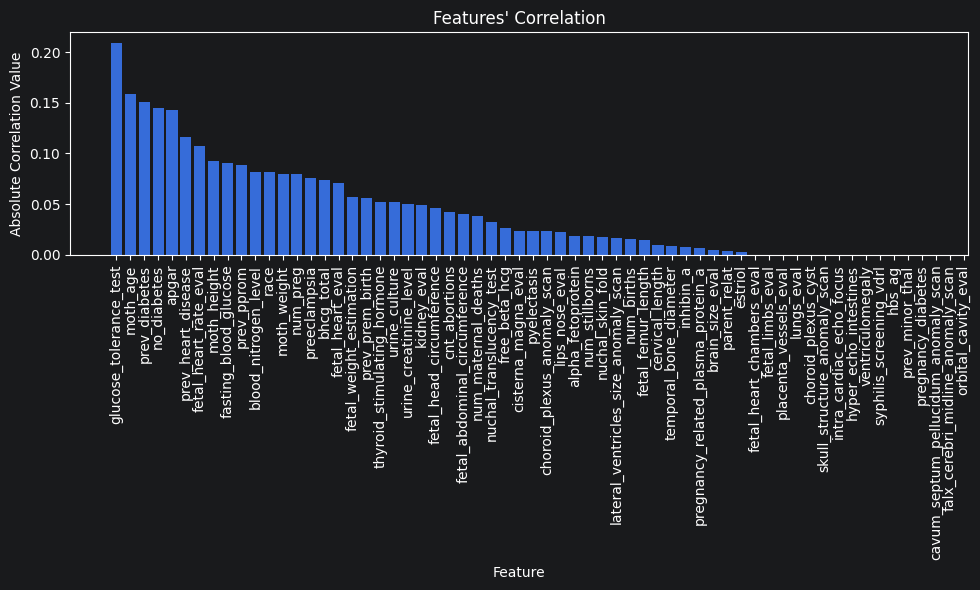

In [54]:
plt.figure(figsize=(10, 6))

plt.bar(combined["feature"], combined["abs_corr"])

plt.xlabel("Feature")
plt.ylabel("Absolute Correlation Value")
plt.title("Features' Correlation")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

This plot shows the Pearson correlation coefficient for each feature with respect to the label. The correlation values indicate how strongly each feature is linearly associated with the target.

Based on the results, none of the features show a strong linear relationship with the label. The highest observed correlation is approximately **0.2**, which corresponds to a weak correlation. In general, correlation values close to 0 indicate little to no linear relationship, while values closer to ±1 indicate strong linear dependence.

Therefore, we can conclude that the predictive relationship between the features and the target is likely non-linear, which is consistent with the use of tree-based models such as Random Forest.


## Each two column
Logistic regression for feature pairs

The purpose of this section is to analyze the interaction effects between pairs of features and their relationship with the target variable.

In [74]:
num_cols = [c for c in df.columns if (c not in ['delivery_method'] and pd.api.types.is_numeric_dtype(df[c]))]

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

df['delivery_method'] = df['delivery_method'].astype(int)

results = []

for col1, col2 in combinations(num_cols, 2):
    formula = f'delivery_method ~ {col1} + {col2} + I({col1}*{col2})'

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        model = smf.logit(formula, data=df).fit(disp=0)

    interaction = f'I({col1} * {col2})'

    results.append({
        'col1': col1,
        'col2': col2,
        'interaction_coef': model.params[interaction],
        'interaction_p_value': model.pvalues[interaction]
    })

results_df = pd.DataFrame(results)
results_df.sort_values('interaction_p_value')

,col1,col2,interaction_coef,interaction_p_value
190,num_maternal_deaths,apgar,0.197564,5.016180e-09
90,num_preg,num_births,-0.214200,1.087803e-06
55,moth_weight,apgar,-0.386694,1.780981e-06
458,fetal_femur_length,lips_nose_eval,0.302764,1.160759e-03
428,temporal_bone_diameter,lips_nose_eval,0.234827,2.411417e-03
...,...,...,...,...
155,num_stillborns,estriol,-1.033842,9.999869e-01
148,num_stillborns,urine_creatinine_level,-0.014943,1.000000e+00
151,num_stillborns,nuchal_translucency_test,150926.996920,NaN
157,num_stillborns,bhcg_total,-0.025263,NaN


For each pair of features, we estimate:

* **Interaction coefficient**:

  * A positive value indicates that increasing both features is associated with a higher probability of the target class.
  * A negative value indicates that increasing both features is associated with a lower probability of the target class.

* **p-value**:
  The p-value measures the statistical significance of the observed interaction effect under the null hypothesis that no relationship exists.

A smaller p-value indicates stronger evidence against the null hypothesis. Conventionally, a threshold of **0.05** is used:

* If **p < 0.05**, the interaction is considered statistically significant.
* If **p ≥ 0.05**, the interaction is considered not statistically significant.

It is important to note that a p-value does not measure the strength of an effect. Instead, it measures how likely it is to observe the result (or something more extreme) if there were actually no true relationship. Therefore, a p-value closer to zero indicates stronger statistical evidence that the interaction is not due to random chance, but it does not directly quantify the magnitude of the effect.

From our analysis, we obtained:

* **34 significant feature pairs (p < 0.05)**
* **459 non-significant feature pairs**

Below are examples of feature pairs with statistically significant interactions (p < 0.05), along with their corresponding plots:

Larger absolute values shows stronger interaction effect and the sign (+ / -) shows the direction of effect.

In [75]:
significant_pairs = results_df[results_df['interaction_p_value'] < 0.05]
non_significant_pairs = results_df[results_df['interaction_p_value'] >= 0.05]

In [76]:
print(significant_pairs.shape)
print(non_significant_pairs.shape)

(34, 4)
(459, 4)


In [77]:
significant_pairs['interaction_coef'] = significant_pairs['interaction_coef'].abs()
significant_pairs = significant_pairs.sort_values(by='interaction_coef', ascending=False)
significant_pairs.head()

,col1,col2,interaction_coef,interaction_p_value
55,moth_weight,apgar,0.386694,0.000002
187,num_maternal_deaths,fetal_weight_estimation,0.347802,0.006118
458,fetal_femur_length,lips_nose_eval,0.302764,0.001161
333,pregnancy_related_plasma_protein_a,fetal_femur_length,0.284565,0.026657
69,moth_height,thyroid_stimulating_hormone,0.258647,0.032407


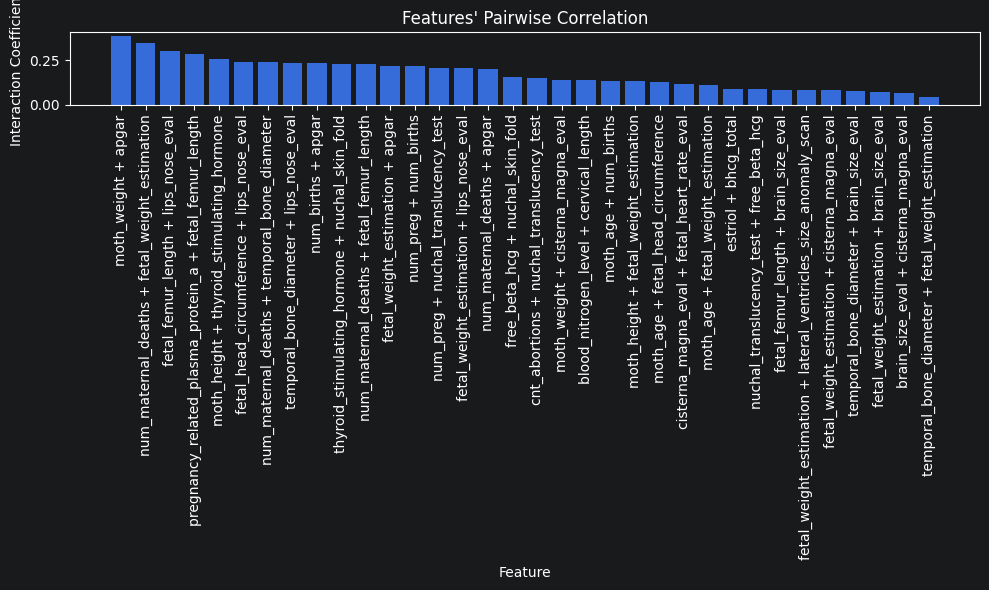

In [79]:
plt.figure(figsize=(10, 6))

plt.bar(significant_pairs["col1"]+" + "+significant_pairs["col2"], significant_pairs["interaction_coef"])

plt.xlabel("Feature")
plt.ylabel("Interaction Coefficient")
plt.title("Features' Pairwise Correlation")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [67]:
significant_cols = list(significant_pairs["col1"]) + list(significant_pairs["col2"])
print(f'Number of columns effected in pairs correlation: {len(set(significant_cols))}')

Number of columns effected in pairs correlation: 26


# Plot Columns' Distribution

In this section, we visualize three selected feature pairs. For each pair, the corresponding plots show the distribution of feature values.

The three pairs were chosen based on their correlation strength with the label:

* The first pair has the highest correlation with the label
* The second pair shows a moderate (medium) correlation
* The third pair has the weakest correlation

These visualizations help illustrate how the strength of correlation is reflected in the separation and distribution patterns of the features with respect to the target variable.

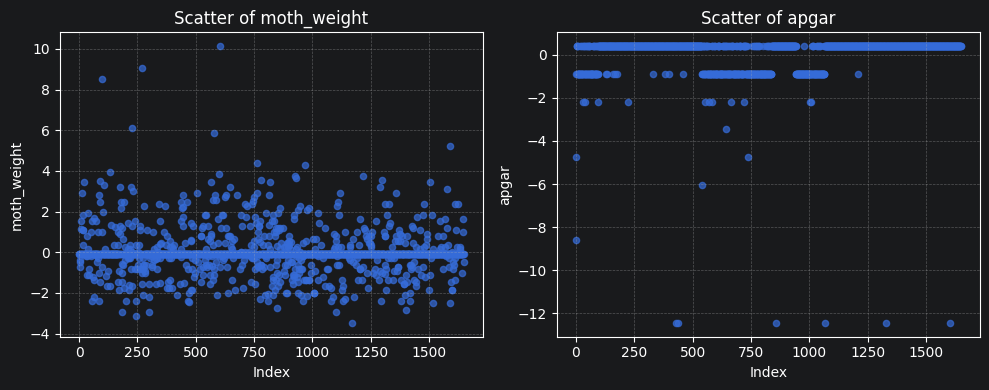

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_col_vals(axes[0], 'moth_weight')
plot_col_vals(axes[1], 'apgar')

plt.tight_layout()
plt.show()

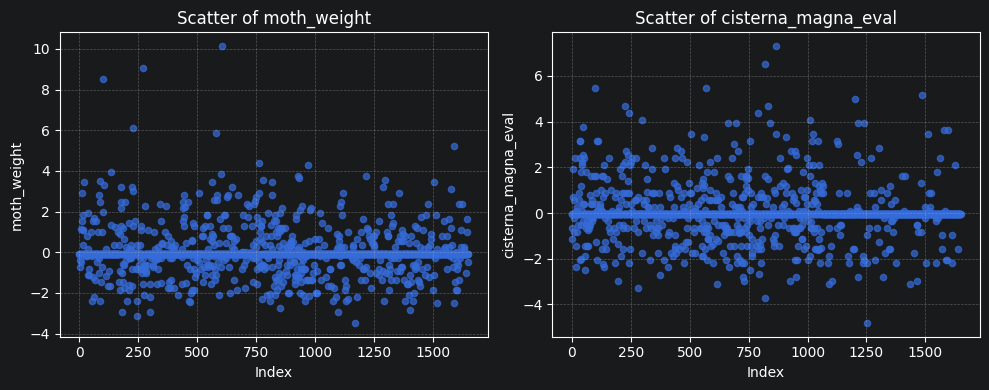

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_col_vals(axes[0], 'moth_weight')
plot_col_vals(axes[1], 'cisterna_magna_eval')

plt.tight_layout()
plt.show()

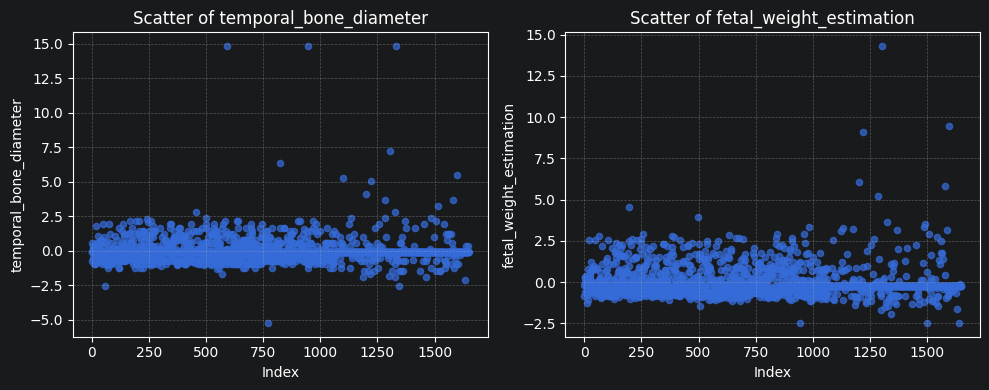

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_col_vals(axes[0], 'temporal_bone_diameter')
plot_col_vals(axes[1], 'fetal_weight_estimation')

plt.tight_layout()
plt.show()

As a result, Pairs with low correlation to the label often look more “similar” in distribution because they do not separate the classes well.

* Low correlation → poor separability → overlapping distributions
* High correlation → better separability → more distinct distributions